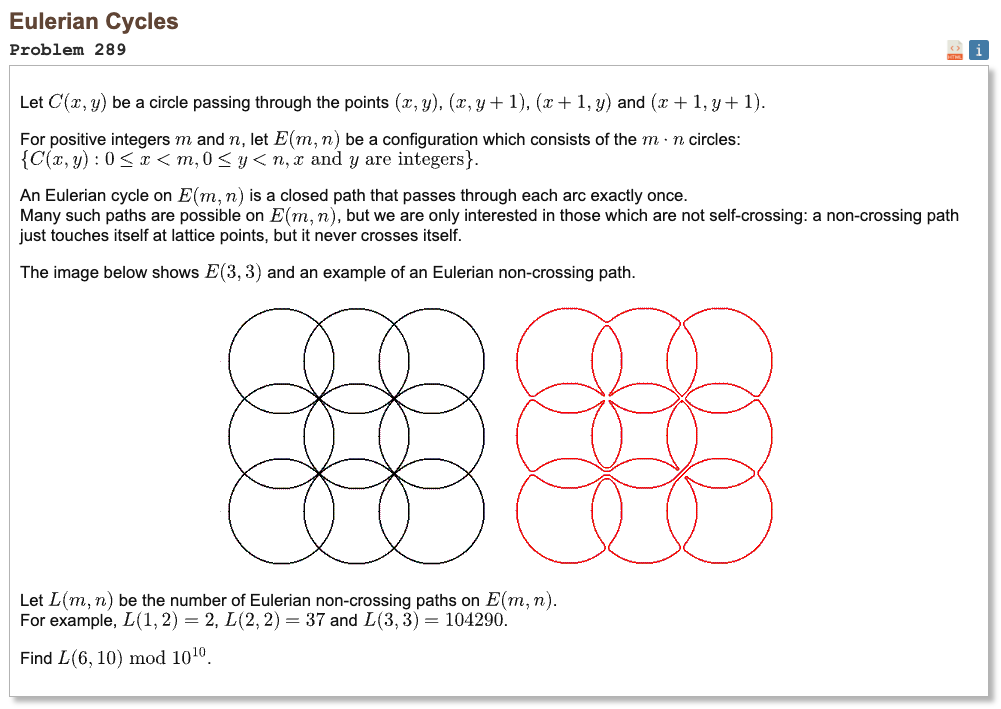

## Initial approach

* scan the picture one lattice point at a time and keep only a narrow frontier, so the problem becomes a transfer dp instead of a huge global search
* at each lattice point, the important objects are the four local regions around that point, not the individual arcs themselves
* there are only 14 valid non crossing ways to connect those four local regions, and those 14 patterns are enough for every step
* the state stores connected component labels for the regions that touch the current frontier
* when a local pattern says two frontier regions become the same, merge their labels, and when a new region is created, give it a fresh temporary label
* after every move, relabel the active components into a canonical compact form, which keeps equivalent states identical and makes the map small
* use functools.lru_cache because the transition list for a given state and row repeats many times across the scan
* run the dp with the smaller dimension as the frontier width, then read the final state 0 as the answer

In [1]:
from functools import lru_cache

def solve():
    n = 10
    m = 6
    mod = 10**10
    connections = [1111, 1114, 1133, 1134, 1131, 1211, 1214, 1221, 1222, 1224, 1231, 1232, 1233, 1234]

    def decode(s):
        state = [0] * (m + 3)
        for i in range(m + 3):
            state[i] = (s >> (4 * i)) & 15
        return state

    def merge_labels(s, x, y):
        i = 0
        while s >> (4 * i):
            if ((s >> (4 * i)) & 15) == x:
                s ^= (x ^ y) << (4 * i)
            i += 1
        return s

    def count_label(s, k):
        total = 0
        for _ in range(m + 4):
            total += (s & 15) == k
            s >>= 4
        return total

    def normalize(s):
        result = 0
        next_id = 0
        seen = [0] * 20
        i = 0
        while s >> (4 * i):
            x = (s >> (4 * i)) & 15
            if seen[x] == 0:
                next_id += 1
                seen[x] = next_id
            result |= (seen[x] - 1) << (4 * i)
            i += 1
        return result

    @lru_cache(None)
    def transitions(k, x, y):
        state = decode(k)
        out = []

        for pattern in connections:
            a = pattern // 1000 - 1
            b = pattern // 100 % 10 - 1
            c = pattern // 10 % 10 - 1
            d = pattern % 10 - 1
            indices = [a, b, c, d]

            new_color = 0 if (y == m or x == n) else 15
            colors = [state[y], state[y + 1], state[y + 2], new_color]
            kk = (k << 4) | new_color
            bad = False

            for i in range(4):
                for j in range(4):
                    if colors[i] == 0 and (((colors[j] == 0) != (indices[i] == indices[j]))):
                        bad = True
                        break
                if bad:
                    break

            if bad:
                continue

            for i in range(4):
                if i == indices[i]:
                    continue

                c_src = (kk >> (4 * (y + i + 1))) & 15
                c_dst = (kk >> (4 * (y + indices[i] + 1))) & 15

                if i == 3:
                    c_src = new_color

                if c_src == 0:
                    continue

                if c_src == c_dst or c_src == 0 or c_dst == 0:
                    kk = -1
                    break

                kk = merge_labels(kk, c_src, c_dst)

            if kk == -1:
                continue

            cur = kk & 15
            kk >>= 4
            old = (kk >> (4 * (y + 1))) & 15

            if count_label(kk, old) > 1 or old == cur or (x == n and y == m):
                kk ^= (cur ^ old) << (4 * (y + 1))
                if y == m:
                    kk <<= 4
                out.append(normalize(kk))

        return tuple(out)

    dp = {0: 1}

    for x in range(n + 1):
        for y in range(m + 1):
            new_dp = {}
            for state, ways in dp.items():
                for nxt in transitions(state, x, y):
                    new_dp[nxt] = (new_dp.get(nxt, 0) + ways) % mod
            dp = new_dp

    result = dp[0] % mod
    print("Result:", result)



In [2]:
%%time
solve()

Result: 6567944538
CPU times: user 853 ms, sys: 9.53 ms, total: 863 ms
Wall time: 864 ms
